In [1]:
import sys
import os
import os
import phydrus as ps
import numpy as np
import warnings
import pandas as pd 
import os
import matplotlib.pyplot as plt
warnings.simplefilter(action='ignore', category=FutureWarning)
%matplotlib inline
current_dir = os.getcwd()

parent_dir = os.path.dirname(current_dir)
sys.path.append(parent_dir)

from model_builder import InfiltrationModel

In [9]:
# Folder for Hydrus files to be stored
ws = "example_3"
# Path to folder containing hydrus.exe 
exe = os.path.join('/Users/onursahin/Flux1Dpy/hydrus_source/source_code/source/hydrus')
# Description
desc = "Root water uptake in a soil profile"
# Create model
ml = ps.Model(exe_name=exe, ws_name=ws, name="model", description=desc, 
              mass_units="mmol", time_unit="days", length_unit="cm")
ml.basic_info["lFlux"] = True
ml.basic_info["lShort"] = False
time = [1, 2, 3, 4, 5, 6, 7, 8, 10, 15, 30]
ml.add_time_info(tmax=30, print_array=time, dt=0.001)
ml.add_waterflow(model=3, top_bc=3, bot_bc=0,ha=0,hb=0)
m = ml.get_empty_material_df(n=1)
m.loc[[1]] = [[0.068, 0.38, 0.008, 1.09, 4.8, 0.5]]
ml.add_material(m)
profile = ps.profile.profile_from_file("/Users/onursahin/Flux1Dpy/test/PROFILE_example3.DAT", ws="profiles")
ml.add_profile(profile)
# Add observation nodes at depth
ml.add_obs_nodes([0, -300])
bc = {"tAtm": (3, 30), "Prec": (2, 0), "rSoil": (0.1, 0.1), "rRoot": (0.5, 1.5)}
atm = pd.DataFrame(bc, index=(3, 30))
ml.add_atmospheric_bc(atm, hcrits=0, hcrita=50000)
ml.add_root_uptake(model=0, crootmax=1, poptm=[-25], omegac=1)
ml.write_input()
ml.simulate()

INFO: Successfully wrote example_3/SELECTOR.IN
INFO: Successfully wrote example_3/PROFILE.DAT
INFO: Successfully wrote example_3/ATMOSPH.IN
INFO: Hydrus-1D Simulation Successful.


CompletedProcess(args=['/Users/onursahin/Flux1Dpy/hydrus_source/source_code/source/hydrus', 'example_3', '-1'], returncode=0)

In [10]:
hydrus_res = ml.read_nod_inf()
df_t = hydrus_res[0]
pond_max= 0.0
discretize = {"layers": [200], "dz": [1.0]} # dummy for this case used from the profle dat from HYDRUS for comparison
flux = np.zeros(30)
trans = np.zeros(30)
flux[0:3],flux[3:] = -1.9/1440,0.1/1440
trans[0:3],trans[3:] = 0.5/1440, 1.5/1440
temp_time  = 1440.0
sim_time = temp_time * flux.shape[0]
bound_bot = 'groundwater level'
bound_top = 'atmospheric'
soil_props = {"tr":[0.068],"ths":[0.38],"a":[0.008],"n": [1.09], "m":[1 - (1 / 1.09)], "ks":[4.8 / 1440], "L":[0.5]}
hyd_model = 'VGM-AE'
model = InfiltrationModel(sim_time,temp_time,discretize,precision=np.float64) #create the model!
model.z = (df_t["Depth"] - df_t["Depth"].min()).values
model.z = model.z[::-1]
model.nodes = model.z.shape[0]

feddes_params = response_feddes = {"p0": -10, "p0opt": -25, "p2h": -200, "p2l": -800,
                   "p3": -8000,"r2h":0.5 / 1440,"r2l":0.1/1440 }
root_model = 'feddes'
hini = df_t['Head'].values[::-1]
root_depth = 200.0 # cm surface to bottom 
root_dist = "uniform" # second option is "uniform"
model.set_soil_model(hyd_model,soil_props,test=True)
model.set_root_model(root_model,feddes_params,root_dist,root_depth)
model.set_boundary_conditions(bound_bot)
hout,sout,sink_out = model.set_run_solver(hini,flux,trans,pond_max,time_interval=1)



/Users/onursahin/Flux1Dpy/solver.py:138: NumbaWarning: Cannot cache compiled function "IterateTime" as it uses dynamic globals (such as ctypes pointers and large global arrays)
  success, new_dt, hx = IterateTime(current_dt, pond, ini_head, flux_top[index], transp[index])
/Users/onursahin/Flux1Dpy/solver.py:138: NumbaWarning: Cannot cache compiled function "update_solution" as it uses dynamic globals (such as ctypes pointers and large global arrays)
  success, new_dt, hx = IterateTime(current_dt, pond, ini_head, flux_top[index], transp[index])
/Users/onursahin/Flux1Dpy/solver.py:111: NumbaWarning: Cannot cache compiled function "RunSolver" as it uses dynamic globals (such as ctypes pointers and large global arrays)
  @njit(cache=True,fastmath=True)


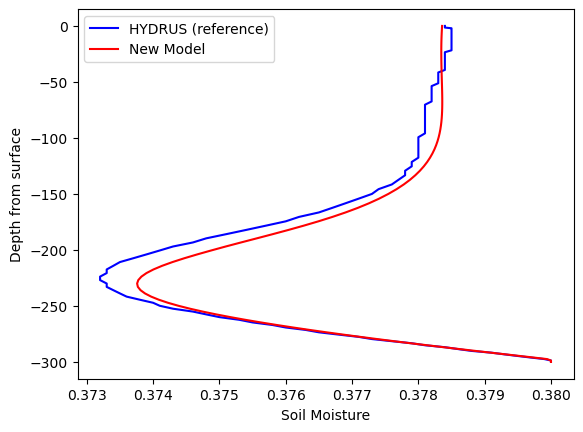

In [11]:
hydrus_res = ml.read_nod_inf()
t = 3
plt.figure()
s_hyd = hydrus_res[t]
plt.plot(s_hyd['Moisture'],s_hyd['Depth'],color='blue',label='HYDRUS (reference)')
plt.plot(sout[int(t),:] ,s_hyd['Depth'][::-1],color='red',label='New Model')
plt.xlabel('Soil Moisture')
plt.ylabel('Depth from surface')
plt.legend()
plt.show()

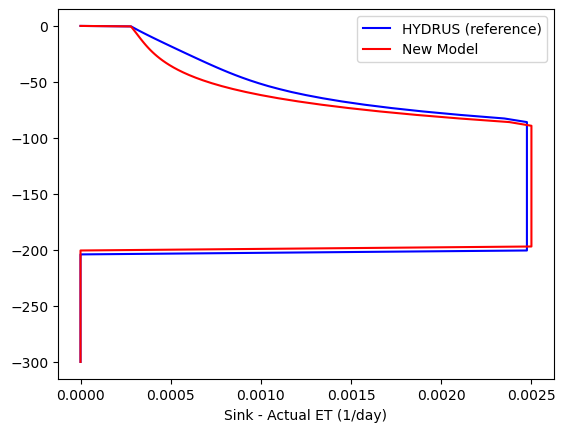

In [16]:

hydrus_res = ml.read_nod_inf()
t = 2
plt.figure()
s_hyd = hydrus_res[t]
plt.plot(s_hyd['Sink'],s_hyd['Depth'],color='blue',label='HYDRUS (reference)')
plt.plot(sink_out[int(t),:]* 1440 ,s_hyd['Depth'][::-1],color='red',label='New Model')
plt.xlabel('Sink - Actual ET (1/day)')
plt.legend()
plt.show()